In [1]:
%load_ext autoreload
%autoreload 1
%aimport Waven.Analysis_Utils
%aimport waven_pipeline
%aimport utils

%matplotlib inline

['spike_times_unit_24f46e34-4ad5-4e60-9c75-d73eba368146.npy', 'spike_times_unit_70d9cab6-27ec-405c-91f8-e1f1cd995412.npy', 'spike_times_unit_5bfdc651-96c4-43e6-9590-0667a5eeb681.npy', 'spike_times_unit_641e7bd3-0b0e-42be-ab33-05dd0160ee77.npy', 'spike_times_unit_7c5739fb-a067-48e7-be6d-56e7a65541ba.npy', 'spike_times_unit_6fe62cab-5425-4c71-86a8-7849f55da26f.npy', 'spike_times_unit_7db9d627-c668-4bf3-b922-49f3bbbc0e39.npy', 'spike_times_unit_ef656b8e-239f-476e-89b2-7888c6e6d06f.npy', 'spike_times_unit_9a9c6bb8-45dd-4110-b4e9-73f0e6a56ae9.npy', 'spike_times_unit_970e6e9b-aaa0-4116-812d-6b03a8c11e8d.npy', 'spike_times_unit_03f841a3-e1b8-4fba-94ac-316783f1665b.npy', 'spike_times_unit_710fdb9a-2721-4f56-b907-91c2df244f31.npy', 'spike_times_unit_c63ffd45-7a2c-4da0-82b8-43226f3020fc.npy', 'spike_times_unit_fa292709-5c6a-4295-9ab0-5ec58ed6f074.npy', 'spike_times_unit_e15874cb-e1fb-4920-a9b8-2c2f51d47f22.npy', 'spike_times_unit_867a0c05-e483-4bda-bef4-a835e3facfeb.npy', 'spike_times_unit_e158c

In [2]:
from waven_pipeline import *
import pandas as pd
import numpy as np
import utils
import matplotlib.pyplot as plt

from tqdm import tqdm

In [3]:
f

0.036

In [3]:
df_gabors = utils.load_all_gabor_rf_results()
df_gabors = df_gabors[df_gabors['p_value']<0.01]
df_gabors = df_gabors[df_gabors['mean_rate']>0]

df_gabors.reset_index(inplace=True, drop=True)
df_gabors

,unit_name,file,orientation,mean_response,z_score_response,p_value,probe,mean_rate
0,3a106cdc-cd82-455d-bfe3-508b82826334,sub-820454_ses-ecephys-820454-2025-11-04-14-59...,0.000000,"[[4.7935867, 4.7935524, 1.1983944, 1.1983651, ...","[[-0.24323879, -0.2432429, -0.6731698, -0.6731...",0.000999,d,6.827611
1,b879a2b0-616e-4e8f-810d-ce8d18ddf293,sub-820454_ses-ecephys-820454-2025-11-04-14-59...,0.785398,"[[22.76965, 26.364311, 32.35631, 25.166029, 25...","[[-0.49844933, -0.31516296, -0.009639895, -0.3...",0.000999,d,32.545372
2,da4242e3-50ca-4b74-83d9-720a02f06906,sub-820454_ses-ecephys-820454-2025-11-04-14-59...,1.570796,"[[9.587265, 3.59514, 7.190285, 0.0, 3.5951731,...","[[0.23058118, -0.48344412, -0.055044398, -0.91...",0.001998,d,7.652220
3,e67204e4-cd09-4ada-8ae2-2642d054a5db,sub-820454_ses-ecephys-820454-2025-11-04-14-59...,1.570796,"[[0.0, 0.0, 1.1983753, 0.0, 1.1983753, 0.0, 0....","[[-0.27198148, -0.27198148, 0.19454516, -0.271...",0.000999,c,0.698644
4,36f937ff-508c-45bd-a792-cac2d26ab6fb,sub-820454_ses-ecephys-820454-2025-11-04-14-59...,0.785398,"[[8.388808, 4.7935014, 5.991878, 11.983837, 8....","[[0.17061816, -0.24076886, -0.103646606, 0.581...",0.000999,c,6.897695
...,...,...,...,...,...,...,...,...
624,df389adc-3104-4596-8a5a-3c298527d8e1,sub-820454_ses-ecephys-820454-2025-11-04-14-59...,1.570796,"[[2.3968067, 1.1983753, 1.1983706, 3.5952103, ...","[[-0.16740166, -0.36361715, -0.36361793, 0.028...",0.000999,c,3.419251
625,eeae91dd-d772-4666-a291-f33e5d23ce55,sub-820454_ses-ecephys-820454-2025-11-04-14-59...,0.000000,"[[4.793602, 3.595126, 0.0, 1.1983562, 1.198394...","[[-0.0029294663, -0.16768587, -0.66191345, -0....",0.006993,c,4.814911
626,65a6a822-9615-47bb-b873-852a96e78802,sub-820454_ses-ecephys-820454-2025-11-04-14-59...,1.570796,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[-0.04975186, -0.04975186, -0.04975186, -0.04...",0.000999,d,0.014795
627,2be4b6b6-90f3-43d6-b8ff-ec3551139e4f,sub-820454_ses-ecephys-820454-2025-11-04-14-59...,1.570796,"[[10.785497, 5.9919467, 1.1983753, 1.1984035, ...","[[1.1724374, 0.422696, -0.32704887, -0.3270444...",0.000999,c,3.289396


In [4]:
df_gabors = df_gabors[(df_gabors['p_value']<0.01) & (df_gabors['mean_rate']>0)]
df_gabors.reset_index(drop=True, inplace=True)

# Set Data dir in utils!

dandiset_id =  utils.dandiset_id
dandi_dirpath = utils.dandi_dirpath
dandi_filepath = df_gabors['file'].unique()[0]

nwb = utils.load_dandi(dandi_filepath, dandiset_id, dandi_dirpath)
df_units = nwb.units.to_dataframe()
df_zebra = nwb.intervals['Zebra_presentations'].to_dataframe()


df_merge = pd.merge(df_gabors, df_units.reset_index(), on='unit_name', how='inner')
df_merge.reset_index(drop=True, inplace=True)


Processing file: sub-820454_ses-ecephys-820454-2025-11-04-14-59-22_ecephys.nwb
File already exists


/home/marcelraabe/miniforge3/envs/waven/lib/python3.9/site-packages/hdmf/common/table.py:512: UserWarning: An attribute 'name' already exists on TimeIntervals '40 hz pulse train_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e.g., table['name'].
  self.__set_table_attr(col)
/home/marcelraabe/miniforge3/envs/waven/lib/python3.9/site-packages/hdmf/common/table.py:512: UserWarning: An attribute 'name' already exists on TimeIntervals '5 hz pulse train_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e.g., table['name'].
  self.__set_table_attr(col)
/home/marcelraabe/miniforge3/envs/waven/lib/python3.9/site-packages/hdmf/common/table.py:512: UserWarning: An attribute 'name' already exists on TimeIntervals 'raised_cosine_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using

In [5]:
spike_times_list = df_merge['spike_times'].values

frame_onset_times = df_zebra['start_time'].values
frame_offset_times = df_zebra['stop_time'].values
unit_names_list = df_merge['unit_name'].values

In [29]:
# delays = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35]
delays = np.arange(0.4, 0.75, 0.05)

RECOMPUTE = True

if RECOMPUTE:
  for delay in delays:
      print(f'Running full pipeline with delay={delay}...')

      full_pipeline(frame_onset_times=frame_onset_times,
                    frame_offset_times=frame_offset_times,
                    spike_times_list=spike_times_list,
                    delay=delay,
                    unit_names_list=unit_names_list,
                  #   results_dir='/home/marcelraabe/projects/SPP2205_local/results/allen_open_scope/rf/waven/zebra/'
                    ) 

Running full pipeline with delay=0.4...
Running Waven Pipeline for delay: 0.4 seconds
Creating Gabor Library...
Downsampling Video...
Wavelet Decomposition...
Computing Neuron Rates to Zebra Frames...
loading wavelets...
already downsampled
Running Correlation Analysis...
torch.Size([4061, 4061])
(629, 3432)
[ 4.48  6.72  8.97 11.21 13.45 17.94]
Saving Results...
Running full pipeline with delay=0.45...
Running Waven Pipeline for delay: 0.45 seconds
Creating Gabor Library...
Downsampling Video...
Wavelet Decomposition...
Computing Neuron Rates to Zebra Frames...
loading wavelets...
already downsampled
Running Correlation Analysis...
torch.Size([4061, 4061])
(629, 3432)
[ 4.48  6.72  8.97 11.21 13.45 17.94]
Saving Results...
Running full pipeline with delay=0.5...
Running Waven Pipeline for delay: 0.5 seconds
Creating Gabor Library...
Downsampling Video...
Wavelet Decomposition...
Computing Neuron Rates to Zebra Frames...
loading wavelets...
already downsampled
Running Correlation Analy

In [31]:
import glob

# Load results
results = []

# Get all files matching the pattern
file_pattern = '../../results/allen_open_scope/rf/waven/zebra/waven-zebra-rfs__delay-*.h5'
files = glob.glob(file_pattern)

# Extract delays from filenames
delays = sorted([float(file.split('__delay-')[-1].replace('.h5', '')) for file in files])
for delay in delays:

    outpath = f'../../results/allen_open_scope/rf/waven/zebra/waven-zebra-rfs__delay-{delay}.h5'
    with h5py.File(outpath, 'r') as file:
        unit_names = list(file.keys())
        opt_sigmas = []
        response_theta_0s = []
        response_theta_45s = []
        response_theta_90s = []

        for unit_name in unit_names:
            grp = file[unit_name]
            opt_simga = grp['opt_sigma'][()]
            response_theta_0 = grp['response_theta_0'][:]
            response_theta_45 = grp['response_theta_45'][:]
            response_theta_90 = grp['response_theta_90'][:]

            
            opt_sigmas.append( opt_simga )
            response_theta_0s.append(response_theta_0)
            response_theta_45s.append(response_theta_45)
            response_theta_90s.append(response_theta_90)


    df_res_waven = pd.DataFrame({'unit_name':unit_names, 
                                'opt_simgas':opt_sigmas, 
                                'response_theta_0':response_theta_0s,
                                'response_theta_45':response_theta_45s,
                                'response_theta_90':response_theta_90s,
                                'delay' : delay, 
                                })
    
    results.append(df_res_waven )
    

df_res = pd.concat(results, ignore_index=True)
df_res

,unit_name,opt_simgas,response_theta_0,response_theta_45,response_theta_90,delay
0,0093d610-ba50-456f-ab83-b29df0c3c4e3,8,"[[-0.03349357, -0.037057053, -0.030007813, -0....","[[0.004001803, -0.0016461409, -0.008984551, -0...","[[0.0005573862, 0.002131928, 0.0046817134, 0.0...",0.0
1,00af6d6a-f6a5-4859-a515-60eced13b218,8,"[[-0.022275984, -0.027494907, -0.031463217, -0...","[[-0.013184262, -0.008066462, -7.004016e-05, 0...","[[0.010515994, 0.01034418, 0.011122161, 0.0144...",0.0
2,013bf7d4-d5d4-4ba6-b254-052c03d476bc,6,"[[-0.024581987, -0.02896271, -0.030686965, -0....","[[-0.013011771, -0.012001856, -0.00437084, 0.0...","[[0.0038263358, 0.0060222964, 0.011337259, 0.0...",0.0
3,01dc5cb5-7e1a-4d93-a4b2-720cf661fe76,6,"[[-0.02959051, -0.03325275, -0.023646595, -0.0...","[[0.0043024616, 0.0030608242, 0.011451146, 0.0...","[[0.016804127, 0.005653845, -0.00669509, 0.008...",0.0
4,021d8351-9579-4246-a356-c981a74f4d4a,6,"[[-0.02815764, -0.02399599, -0.016329532, -0.0...","[[-0.004389307, -0.002035741, 0.0007413101, -0...","[[0.013671849, 0.008746105, -0.0023065927, 0.0...",0.0
...,...,...,...,...,...,...
4990,fb708f5b-3c36-4f9a-80ec-2065c84ddaf4,6,"[[-0.020795079, -0.02608379, -0.024137141, -0....","[[-0.0036470057, -0.0021294027, -0.0019003625,...","[[-0.00023632866, 0.00039037538, 0.007951305, ...",0.7
4991,fbafc39b-2b5d-43d3-9fa1-5a1793cc5eaa,8,"[[-0.02431267, -0.03320014, -0.026639832, -0.0...","[[-0.0014650144, -0.008070541, -0.010320162, -...","[[0.01660981, 0.017930526, 0.01917032, 0.02721...",0.7
4992,fee458f3-90d4-44e6-8845-4d4c89a2a04d,4,"[[-0.0116794435, -0.023049308, -0.023953017, -...","[[0.0038327486, -0.004283905, -0.014509412, -0...","[[-0.00028978215, -0.00022136541, -0.005528459...",0.7
4993,fee50e24-0b2a-4c36-8d46-02187d015638,4,"[[-0.0006240712, -0.008386841, -0.026576113, -...","[[0.015910026, 0.015253421, -0.0026153962, 0.0...","[[0.020257263, 0.01963054, 0.0005638673, 0.009...",0.7


In [53]:
unit_names = df_res['unit_name'].unique()

maxs = []
for unit_name in tqdm(unit_names):
    df_tmp = df_res.loc[df_res['unit_name']==unit_name]

    max_per_delay = []
    for delay in delays:
        response_theta_0 = df_tmp.loc[df_tmp['delay']==delay, 'response_theta_0'].values[0]
        response_theta_45 = df_tmp.loc[df_tmp['delay']==delay, 'response_theta_45'].values[0]
        response_theta_90 = df_tmp.loc[df_tmp['delay']==delay, 'response_theta_90'].values[0]

        # max_i= np.max( [response_theta_0, response_theta_45, response_theta_90] )
        max_i= np.max(response_theta_0)

        max_per_delay.append(max_i)
    maxs.append(max_per_delay)

maxs = np.array(maxs)
maxs.shape


100%|██████████| 333/333 [00:01<00:00, 228.58it/s]


(333, 15)

Text(0.5, 1.0, 'Wavelet approach\nMax correlation per delay across units')

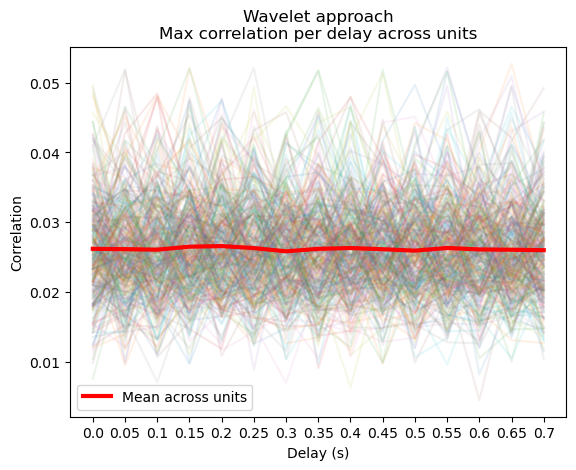

In [42]:
_ = plt.plot(maxs.T, alpha=0.1)
_ = plt.plot(np.mean(maxs, axis=0), alpha=1, color='r', label='Mean across units', linewidth=3)

delay_ticks = np.round(delays,2) 
_ = plt.xticks( range(len(delays)), delay_ticks)
_ = plt.xlabel('Delay (s)')
_ = plt.ylabel('Correlation')


plt.legend()
plt.title('Wavelet approach\nMax correlation per delay across units')

In [43]:
delays_i = np.tile(delays, (maxs.shape[0], 1))

max_args = np.argmax(maxs, axis=1)
max_delay_i = [delays[idx] for idx in max_args]
delays_to_delay_max = delays_i - np.array(max_delay_i)[:, None]
delays_to_delay_max.shape
delays_to_delay_max = np.stack([delays_to_delay_max, maxs], axis=2)
delays_to_delay_max.shape

(333, 15, 2)

In [44]:
max

<function max>

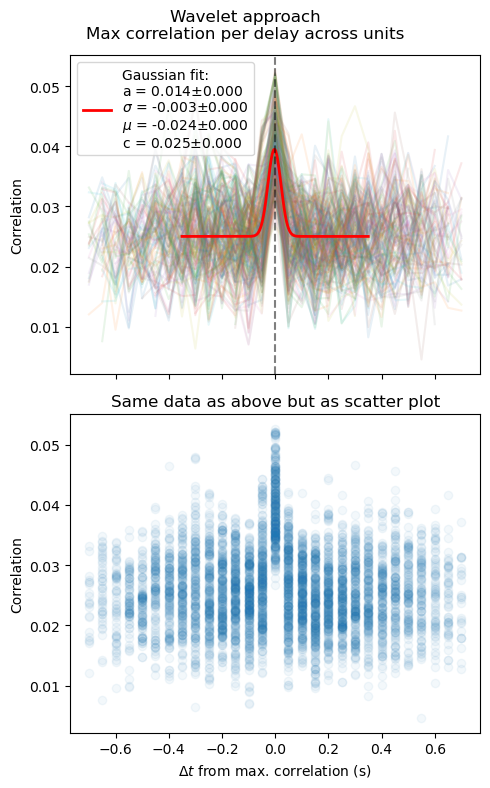

In [45]:
from scipy.optimize import curve_fit

delays_i = np.tile(delays, (maxs.shape[0], 1))

max_args = np.argmax(maxs, axis=1)
max_delay_i = [delays[idx] for idx in max_args]
delays_to_delay_max = delays_i - np.array(max_delay_i)[:, None]


f, ax = plt.subplots(2,1, figsize=(5,8), sharex=True, sharey=True)

_ = ax[0].plot(delays_to_delay_max.T, maxs.T, alpha=0.1)

# Define Gaussian function
def gaussian(x, a, x0, sigma, const):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2)) + const

# Fit Gaussian to the mean curve
mean_curve = np.mean(maxs, axis=0)
popt, pcov = curve_fit(gaussian, delays_to_delay_max.flatten(), maxs.flatten())
# perr = np.sqrt(np.diag(pcov))

x= delays_to_delay_max.flatten()
y= maxs.flatten()
resid = y - gaussian(x, *popt)
dof = max(1, len(y) - len(popt))
s2 = np.sum(resid**2) / dof           # reduced chi-square
pcov_scaled = pcov * s2
perr = np.sqrt(np.diag(pcov_scaled))

# Plot the fitted Gaussian
xdata = np.linspace(-0.35, 0.35, 1000)
fitted_curve = gaussian(xdata, *popt)
_ = ax[0].plot(xdata, fitted_curve, color='r', label=f'Gaussian fit:\na = {popt[0]:.3f}$\pm${perr[0]:.3f}\n$\sigma$ = {popt[1]:.3f}$\pm${perr[1]:.3f}\n$\mu$ = {popt[2]:.3f}$\pm${perr[2]:.3f}\nc = {popt[3]:.3f}$\pm${perr[3]:.3f}', linewidth=2)



ax[0].axvline(0, color='k', linestyle='--', alpha=0.5)
ax[1].scatter(delays_to_delay_max.flatten(), maxs.flatten(), alpha=0.05)
# ax[1].plot(xdata, fitted_curve, color='r', label='Gaussian fit', linewidth=2)



ax[1].set_xlabel('$\Delta t$ from max. correlation (s)')
ax[0].set_ylabel('Correlation')
ax[1].set_ylabel('Correlation')
ax[0].legend()
f.suptitle('Wavelet approach\nMax correlation per delay across units')

ax[1].set_title('Same data as above but as scatter plot')
f.tight_layout()

Text(0, 0.5, 'Number of units')

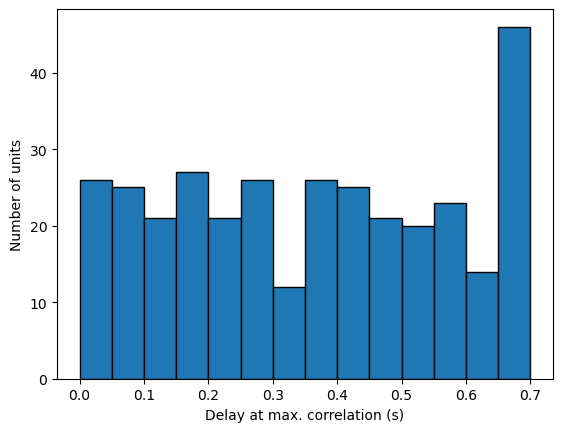

In [47]:
plt.hist(max_delay_i, bins=delays, edgecolor='black')

plt.xlabel('Delay at max. correlation (s)')
plt.ylabel('Number of units')

100%|██████████| 333/333 [00:00<00:00, 623.45it/s]


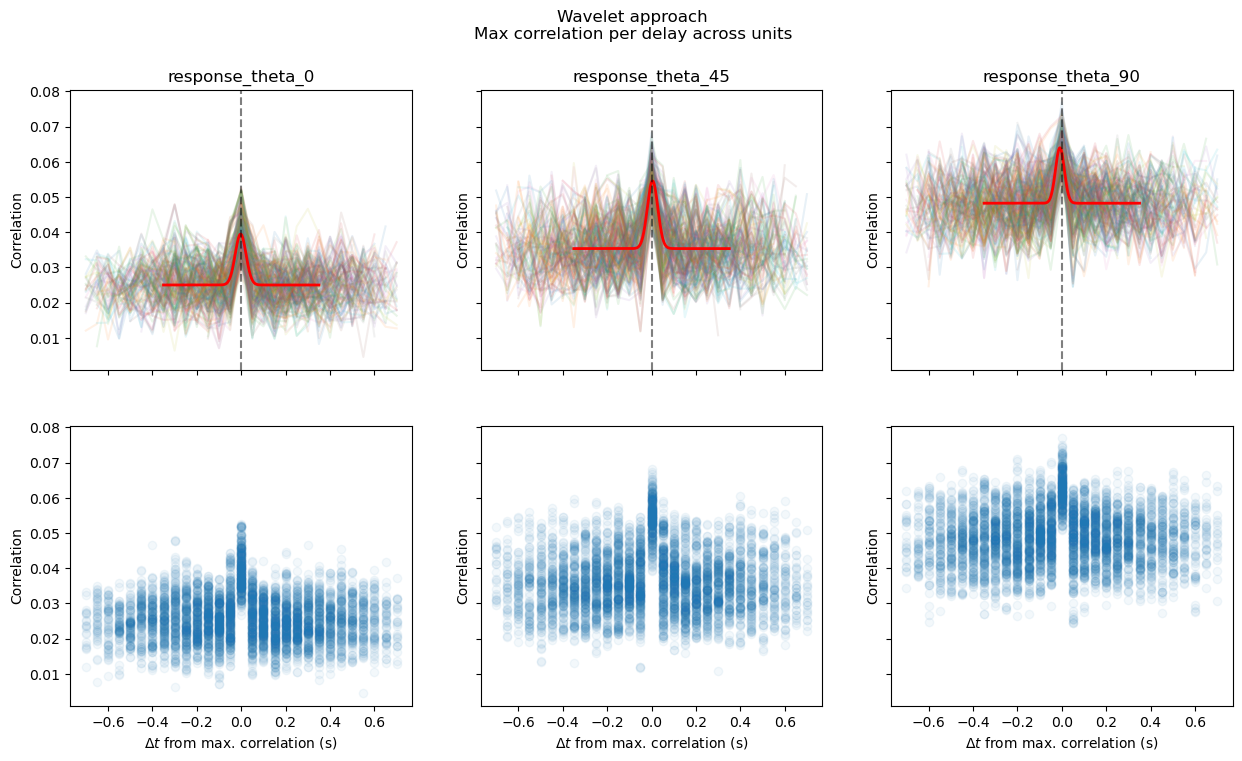

In [52]:
unit_names = df_res['unit_name'].unique()

f, axs = plt.subplots(2,3, figsize=(15,8), sharex=True, sharey=True)


for i, key in enumerate(['response_theta_0', 'response_theta_45', 'response_theta_90']):
    maxs = []
    for unit_name in tqdm(unit_names):
        df_tmp = df_res.loc[df_res['unit_name']==unit_name]

        max_per_delay = []
        for delay in delays:
            response_theta_0 = df_tmp.loc[df_tmp['delay']==delay, key].values[0]
            max_i= np.max(response_theta_0)

            max_per_delay.append(max_i)
        maxs.append(max_per_delay)

    maxs = np.array(maxs)


    delays_i = np.tile(delays, (maxs.shape[0], 1))

    max_args = np.argmax(maxs, axis=1)
    max_delay_i = [delays[idx] for idx in max_args]
    delays_to_delay_max = delays_i - np.array(max_delay_i)[:, None]

    ax = axs[:, i]

    _ = ax[0].plot(delays_to_delay_max.T, maxs.T, alpha=0.1)

    # Define Gaussian function
    def gaussian(x, a, x0, sigma, const):
        return a * np.exp(-(x - x0)**2 / (2 * sigma**2)) + const

    # Fit Gaussian to the mean curve
    mean_curve = np.mean(maxs, axis=0)
    popt, pcov = curve_fit(gaussian, delays_to_delay_max.flatten(), maxs.flatten())
    # perr = np.sqrt(np.diag(pcov))

    x= delays_to_delay_max.flatten()
    y= maxs.flatten()
    resid = y - gaussian(x, *popt)
    dof = max(1, len(y) - len(popt))
    s2 = np.sum(resid**2) / dof           # reduced chi-square
    pcov_scaled = pcov * s2
    perr = np.sqrt(np.diag(pcov_scaled))

    # Plot the fitted Gaussian
    xdata = np.linspace(-0.35, 0.35, 1000)
    fitted_curve = gaussian(xdata, *popt)
    _ = ax[0].plot(xdata, fitted_curve, color='r', label=f'Gaussian fit:\na = {popt[0]:.3f}$\pm${perr[0]:.3f}\n$\sigma$ = {popt[1]:.3f}$\pm${perr[1]:.3f}\n$\mu$ = {popt[2]:.3f}$\pm${perr[2]:.3f}\nc = {popt[3]:.3f}$\pm${perr[3]:.3f}', linewidth=2)



    ax[0].axvline(0, color='k', linestyle='--', alpha=0.5)
    ax[1].scatter(delays_to_delay_max.flatten(), maxs.flatten(), alpha=0.05)
    # ax[1].plot(xdata, fitted_curve, color='r', label='Gaussian fit', linewidth=2)



    ax[1].set_xlabel('$\Delta t$ from max. correlation (s)')
    ax[0].set_ylabel('Correlation')
    ax[1].set_ylabel('Correlation')
    # ax[0].legend()
    f.suptitle('Wavelet approach\nMax correlation per delay across units')

    ax[0].set_title(key)

In [57]:
unit_names = df_res['unit_name'].unique()

maxs = []
for unit_name in tqdm(unit_names):
    df_tmp = df_res.loc[df_res['unit_name']==unit_name]

    max_per_delay = []
    for delay in delays:
        response_theta_0 = df_tmp.loc[df_tmp['delay']==delay, 'response_theta_0'].values[0]
        response_theta_45 = df_tmp.loc[df_tmp['delay']==delay, 'response_theta_45'].values[0]
        response_theta_90 = df_tmp.loc[df_tmp['delay']==delay, 'response_theta_90'].values[0]

        max_i= np.argmax( [np.max(response_theta_0), np.max(response_theta_45), np.max(response_theta_90)] )

        # max_i= np.max( [response_theta_0, response_theta_45, response_theta_90] )
        max_i= np.max(max_i)

        max_per_delay.append(max_i)
    maxs.append(max_per_delay)

maxs = np.array(maxs)
maxs

100%|██████████| 333/333 [00:01<00:00, 222.46it/s]


array([[2, 2, 2, ..., 2, 2, 1],
       [2, 2, 2, ..., 2, 2, 2],
       [2, 2, 2, ..., 1, 2, 2],
       ...,
       [2, 1, 2, ..., 1, 2, 1],
       [2, 2, 1, ..., 2, 2, 1],
       [2, 2, 2, ..., 2, 2, 2]])

In [64]:
df_tmp = df_res.loc[df_res['unit_name']==unit_name]

avg_max_per_key = []
for i, key in enumerate(['response_theta_0', 'response_theta_45', 'response_theta_90']):
    max_per_key = []
    for j, delay in enumerate(delays):
        max_key = np.max(df_tmp.loc[df_tmp['delay']==delay, key].values[0])
        max_per_key.append(max_key)
    avg_max_per_key.append( np.mean(max_per_key) )
max_i = np.argmax(avg_max_per_key)
max_i

2

In [67]:
unit_names = df_res['unit_name'].unique()


keys = ['response_theta_0', 'response_theta_45', 'response_theta_90']

maxs_dict = {}
for unit_name in tqdm(unit_names):
    df_tmp = df_res.loc[df_res['unit_name']==unit_name]

    avg_max_per_key = []
    for i, key in enumerate(keys):
        max_per_key = []
        for j, delay in enumerate(delays):
            max_key = np.max(df_tmp.loc[df_tmp['delay']==delay, key].values[0])
            max_per_key.append(max_key)
        avg_max_per_key.append( np.mean(max_per_key) )
    max_i = np.argmax(avg_max_per_key)

    max_per_delay = []
    for delay in delays:
        response_theta = df_tmp.loc[df_tmp['delay']==delay, keys[max_i]].values[0]
        max_response = np.max(response_theta)
        max_per_delay.append(max_response)
    maxs_dict.setdefault(keys[max_i], []).append(max_per_delay)



100%|██████████| 333/333 [00:02<00:00, 123.65it/s]


In [71]:
maxs_dict.keys()

dict_keys(['response_theta_90'])

In [ ]:
maxs_dict

KeyError: 'response_theta_0'

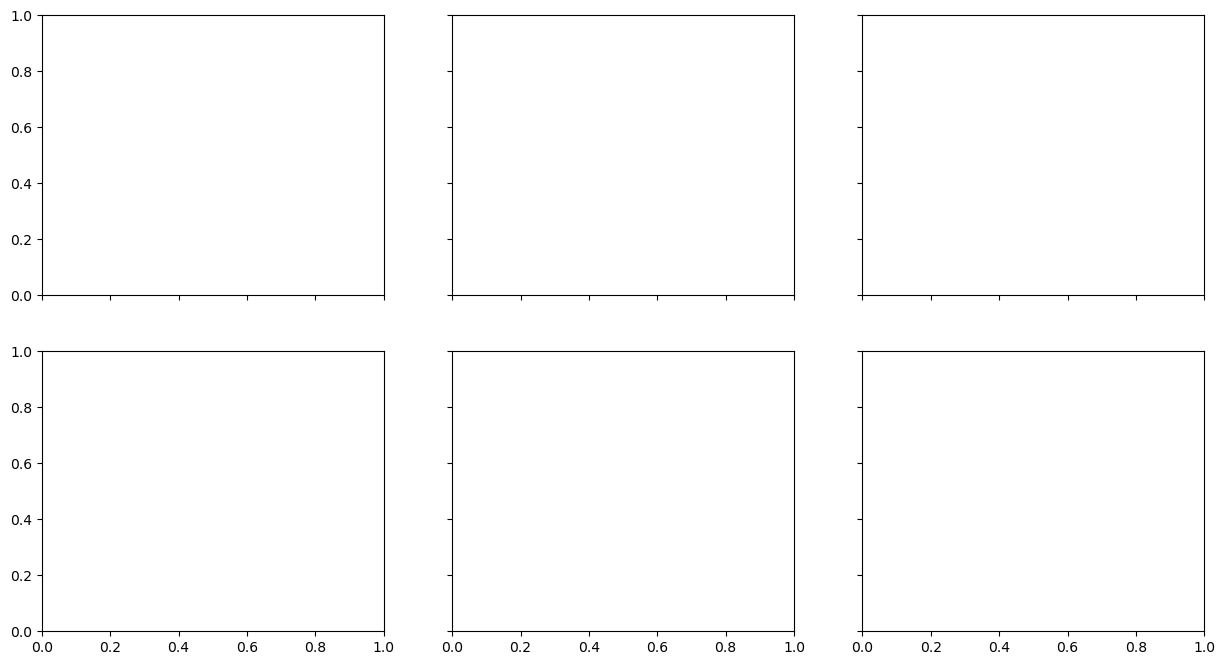

In [69]:

f, axs = plt.subplots(2,3, figsize=(15,8), sharex=True, sharey=True)


for i, key in enumerate(keys):
    maxs = np.array( maxs_dict[key] )


    delays_i = np.tile(delays, (maxs.shape[0], 1))

    max_args = np.argmax(maxs, axis=1)
    max_delay_i = [delays[idx] for idx in max_args]
    delays_to_delay_max = delays_i - np.array(max_delay_i)[:, None]

    ax = axs[:, i]

    _ = ax[0].plot(delays_to_delay_max.T, maxs.T, alpha=0.1)

    # Define Gaussian function
    def gaussian(x, a, x0, sigma, const):
        return a * np.exp(-(x - x0)**2 / (2 * sigma**2)) + const

    # Fit Gaussian to the mean curve
    mean_curve = np.mean(maxs, axis=0)
    popt, pcov = curve_fit(gaussian, delays_to_delay_max.flatten(), maxs.flatten())
    # perr = np.sqrt(np.diag(pcov))

    x= delays_to_delay_max.flatten()
    y= maxs.flatten()
    resid = y - gaussian(x, *popt)
    dof = max(1, len(y) - len(popt))
    s2 = np.sum(resid**2) / dof           # reduced chi-square
    pcov_scaled = pcov * s2
    perr = np.sqrt(np.diag(pcov_scaled))

    # Plot the fitted Gaussian
    xdata = np.linspace(-0.35, 0.35, 1000)
    fitted_curve = gaussian(xdata, *popt)
    _ = ax[0].plot(xdata, fitted_curve, color='r', label=f'Gaussian fit:\na = {popt[0]:.3f}$\pm${perr[0]:.3f}\n$\sigma$ = {popt[1]:.3f}$\pm${perr[1]:.3f}\n$\mu$ = {popt[2]:.3f}$\pm${perr[2]:.3f}\nc = {popt[3]:.3f}$\pm${perr[3]:.3f}', linewidth=2)


